In [1]:
import json

import numpy as np

In [2]:

with open("osg_astar_mice_results.json") as f:
    data = json.load(f)

for strategy, programs in data["strategies"].items():
    print(f"\n{'=' * 70}")
    print(f"  {strategy}")
    print(f"{'=' * 70}")
    print(f"  {'#':<4} {'Latency':>10} {'Inv F1':>10} {'Not-Inv F1':>12}  Program")
    print(f"  {'-'*4} {'-'*10} {'-'*10} {'-'*12}  {'-'*30}")
    for i, p in enumerate(programs):
        print(
            f"  {i:<4} {p['latency']:>9.1f}s"
            f" {p['investigation_f1']:>10.4f}"
            f" {p['not_investigation_f1']:>12.4f}"
            f"  {p['program']}"
        )


  AStar
  #       Latency     Inv F1   Not-Inv F1  Program
  ---- ---------- ---------- ------------  ------------------------------
  0         14.2s     0.5794       0.7549  (output (mul (running_avg_last5 (affine_res_angle_head_body)) (running_avg_window5 (affine_overlap_bboxes))))
  1         15.6s     0.4516       0.4051  (output (mul (running_avg_last5 (affine_res_angle_head_body)) (running_avg_last5 (affine_overlap_bboxes))))
  2         16.8s     0.1887       0.8626  (output (mul (running_avg_last5 (affine_res_angle_head_body)) (running_avg_window11 (affine_overlap_bboxes))))
  3         18.1s     0.3892       0.0593  (output (mul (running_avg_last5 (affine_res_angle_head_body)) (running_avg_last10 (affine_overlap_bboxes))))
  4         18.1s     0.3871       0.0000  (output (mul (running_avg_last5 (affine_res_angle_head_body)) (running_avg_window5 (affine_res_angle_head_body))))
  5         18.1s     0.2424       0.3529  (output (mul (running_avg_last5 (affine_res_angle_head_

In [3]:
print(f"\n{'=' * 70}")
print("  Summary")
print(f"{'=' * 70}")
print(f"  {'Strategy':<30} {'First':>8} {'Last':>8} {'Best Inv':>10} {'Best NI':>10} {'Mean Inv':>10} {'Mean NI':>10}")
print(f"  {'-'*30} {'-'*8} {'-'*8} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
for strategy, programs in data["strategies"].items():
    lats = [p["latency"] for p in programs]
    inv = [p["investigation_f1"] for p in programs]
    ni = [p["not_investigation_f1"] for p in programs]
    print(
        f"  {strategy:<30}"
        f" {min(lats):>7.1f}s"
        f" {max(lats):>7.1f}s"
        f" {max(inv):>10.4f}"
        f" {max(ni):>10.4f}"
        f" {sum(inv)/len(inv):>10.4f}"
        f" {sum(ni)/len(ni):>10.4f}"
    )


  Summary
  Strategy                          First     Last   Best Inv    Best NI   Mean Inv    Mean NI
  ------------------------------ -------- -------- ---------- ---------- ---------- ----------
  AStar                             14.2s    32.6s     0.5794     0.8626     0.3172     0.5009
  OSGAstar                           8.4s    11.1s     0.5576     0.8636     0.2892     0.4666


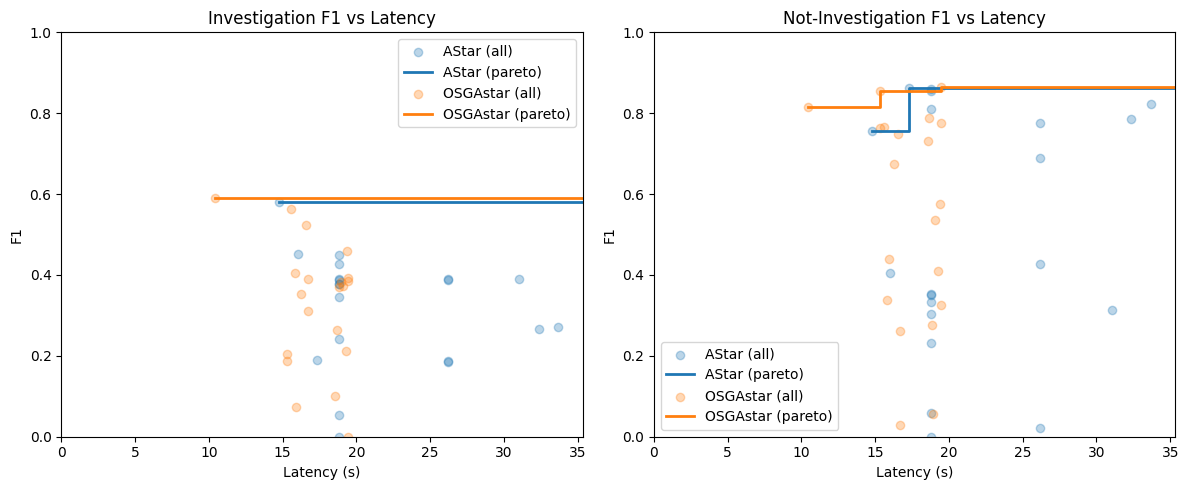

In [11]:
import matplotlib.pyplot as plt


def pareto_frontier(lats, f1s):
    """Compute the Pareto frontier: best F1 seen so far at each latency."""
    paired = sorted(zip(lats, f1s))
    pareto_lats, pareto_f1s = [], []
    best = -1
    for t, f in paired:
        if f > best:
            best = f
            pareto_lats.append(t)
            pareto_f1s.append(f)
    return pareto_lats, pareto_f1s


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Collect all latencies to set consistent x limits
all_lats = [p["latency"] for progs in data["strategies"].values() for p in progs]
x_max = max(all_lats) * 1.05

for strategy, programs in data["strategies"].items():
    lats = [p["latency"] for p in programs]
    inv = [p["investigation_f1"] for p in programs]
    ni = [p["not_investigation_f1"] for p in programs]

    # Scatter all points
    axes[0].scatter(lats, inv, alpha=0.3, label=f"{strategy} (all)")
    axes[1].scatter(lats, ni, alpha=0.3, label=f"{strategy} (all)")

    # Pareto curve — extend to x_max so the final level is visible
    for ax, f1s in [(axes[0], inv), (axes[1], ni)]:
        p_lats, p_f1s = pareto_frontier(lats, f1s)
        p_lats.append(x_max)
        p_f1s.append(p_f1s[-1])
        ax.step(p_lats, p_f1s, where="post", linewidth=2, label=f"{strategy} (pareto)")

axes[0].set_xlabel("Latency (s)")
axes[0].set_ylabel("F1")
axes[0].set_title("Investigation F1 vs Latency")
axes[0].legend()

axes[1].set_xlabel("Latency (s)")
axes[1].set_ylabel("F1")
axes[1].set_title("Not-Investigation F1 vs Latency")
axes[1].legend()

for ax in axes:
    ax.set_ylim(0, 1)
    ax.set_xlim(0, x_max)

fig.tight_layout()
plt.show()

In [12]:
# Compare time to reach best F1 on each Pareto frontier
for label, key in [("Investigation", "investigation_f1"), ("Not-Investigation", "not_investigation_f1")]:
    print(f"\n{label} F1:")
    for strategy, programs in data["strategies"].items():
        lats = [p["latency"] for p in programs]
        f1s = [p[key] for p in programs]
        p_lats, p_f1s = pareto_frontier(lats, f1s)
        print(f"  {strategy:<12} best={p_f1s[-1]:.4f} @ {p_lats[-1]:.1f}s  (first={p_f1s[0]:.4f} @ {p_lats[0]:.1f}s)")


Investigation F1:
  AStar        best=0.5794 @ 14.8s  (first=0.5794 @ 14.8s)
  OSGAstar     best=0.5911 @ 10.4s  (first=0.5911 @ 10.4s)

Not-Investigation F1:
  AStar        best=0.8626 @ 17.3s  (first=0.7549 @ 14.8s)
  OSGAstar     best=0.8636 @ 19.5s  (first=0.8161 @ 10.4s)
